In [12]:
from google.colab import files
files.upload()

Saving archive.zip to archive.zip


{'archive.zip': b'PK\x03\x04-\x00\x00\x08\x08\x00\x98L>\\\x9bL6i\xff\xff\xff\xff\xff\xff\xff\xff&\x00\x14\x00semiconductor_wafer_defect_dataset.csv\x01\x00\x10\x00\x88\x93\t\x00\x00\x00\x00\x00/`\x04\x00\x00\x00\x00\x00l\xdd\xd9\xae$[z$\xe6\xfb~\x96\x8d\r\xf7\xe5\xf3\xb5\xa4;\t\xd2\x1b\x14(vu7\x81\xe6\x80biz{\xd9g+2\x99\x11\xbbI\x90,\x9e\x93\x19\xee\xbe\x86\x7f4\xb3\xff\xff\xf9\x87\xff\xf2\xd7\xbf\xfd\xe5\x9f\xfe\xf3\xd7\xdf\xff\xfa\xcf\xff\xf6\xd7\xbf\xfd\xc3\xdf\xff\xaf\xbf\xfd\xf5/\xff\xf8\xf5o\x7f\xfb\xeb\xbf\xff\xbb\xff\xf8\xf7\x7f\xfd\xdb\xdf\xbe\xfe\xeb?\xfc\xfb_\xfe\xcb\x7f\xff\xd7\xff\xe7/\xff\xfe\x8f\xff\xf8\xcf_\x7f\xfd\xfb?\xfe\xb7\xbf\xe4O\xfe\xf5/\xff\xf2\xcf\x7f\xf9\xe7\x7f\xfa\x97\xaf\xff\xfb_\xff\xfb\xdf\xff\xe1\xbf\xfe\xf5/\xff\xf7\xd7?\xfe_\x7f\xfb\xdb_\xff\xe5\xef\x7f\xf9\xe7\x7f\xc8/\xfc\xeb?\xe67\xfe\xf2\xef\x7f\xff\xeb\xbf}\xfd\xe7\xbf\xfe\x97\xbf\xfe\xe3\xdf\xff\xf2\xdf\xff\xe1\xff\xfc\xeb\x7f\xffO\xeb\xd7~\\\xdf\xfb\xb1\\\xeb\x18\xcf\xb1\x9e\xf7\xf1u\xed\xd7\xf

In [14]:
!unzip archive.zip

Archive:  archive.zip
  inflating: semiconductor_wafer_defect_dataset.csv  


In [16]:
import pandas as pd

df = pd.read_csv("semiconductor_wafer_defect_dataset.csv")

print(df.head())

   wafer_id  temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  \
0         1     457.450712     747.287210     113.215053         93.852614   
1         2     447.926035     746.397577     116.945005         94.738753   
2         3     459.715328     706.130705     114.026189         95.514359   
3         4     472.845448     750.097294     121.104180        102.574892   
4         5     446.487699     781.984872     131.971785         89.022262   

   voltage_v  current_ma process_step  defect_label  
0   5.139314   20.341747   Deposition             0  
1   5.113329   20.024511  Lithography             0  
2   4.625392   19.137690   Deposition             0  
3   5.231834   19.994947   Deposition             0  
4   4.403967   20.981683   Deposition             0  


In [17]:
print(df.shape)
print(df.columns)

(5000, 9)
Index(['wafer_id', 'temperature_c', 'pressure_torr', 'gas_flow_sccm',
       'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step',
       'defect_label'],
      dtype='object')


In [19]:
X = df.drop(["wafer_id", "defect_label"], axis=1)
y = df["defect_label"]

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.998


## Data Checking for Imbalanced Dataset

In [23]:
print(y.value_counts())

defect_label
0    4993
1       7
Name: count, dtype: int64


In [24]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[998   0]
 [  2   0]]


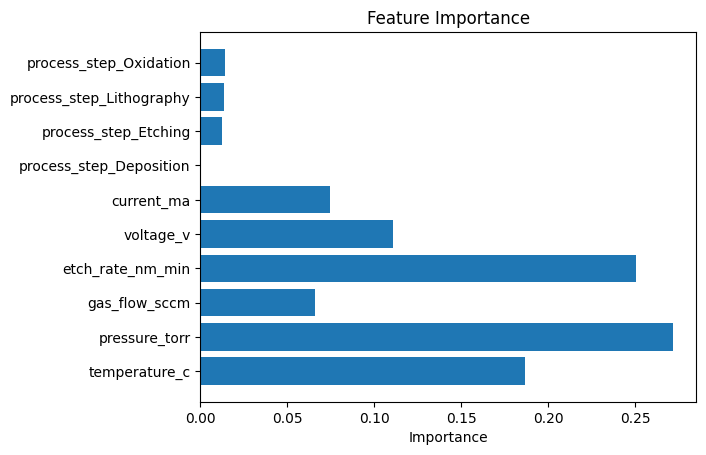

In [27]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()


First 5 rows:
    wafer_id  temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  \
0         1     457.450712     747.287210     113.215053         93.852614   
1         2     447.926035     746.397577     116.945005         94.738753   
2         3     459.715328     706.130705     114.026189         95.514359   
3         4     472.845448     750.097294     121.104180        102.574892   
4         5     446.487699     781.984872     131.971785         89.022262   

   voltage_v  current_ma process_step  defect_label  
0   5.139314   20.341747   Deposition             0  
1   5.113329   20.024511  Lithography             0  
2   4.625392   19.137690   Deposition             0  
3   5.231834   19.994947   Deposition             0  
4   4.403967   20.981683   Deposition             0  

Dataset shape: (5000, 9)

Columns: Index(['wafer_id', 'temperature_c', 'pressure_torr', 'gas_flow_sccm',
       'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step',
       'defect_l

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


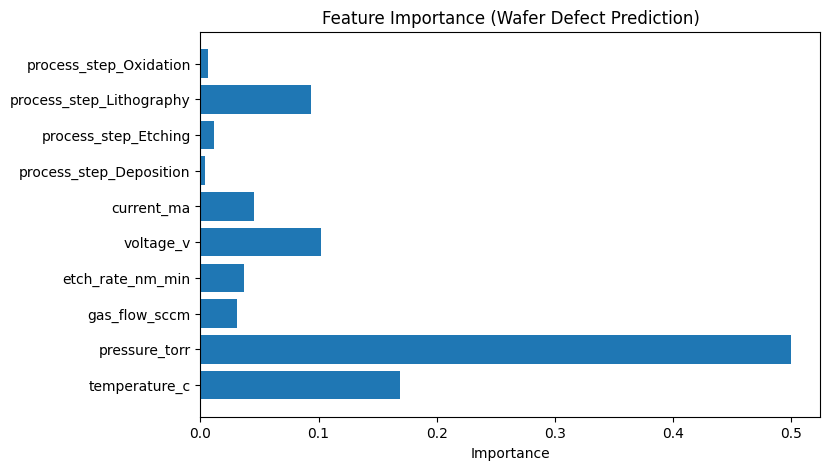

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       998\n           1       0.00      0.00      0.00         2\n\n    accuracy                           1.00      1000\n   macro avg       0.50      0.50      0.50      1000\nweighted avg       1.00      1.00      1.00      1000\n'

In [32]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt


# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

df = pd.read_csv("semiconductor_wafer_defect_dataset.csv")

print("First 5 rows:\n", df.head())


# ============================================================
# STEP 3: UNDERSTAND DATA
# ============================================================

print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns)

print("\nClass distribution:\n", df["defect_label"].value_counts())


# ============================================================
# STEP 4: PREPROCESS DATA
# ============================================================

# Drop ID column
X = df.drop(["wafer_id", "defect_label"], axis=1)

# Target
y = df["defect_label"]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)


# ============================================================
# STEP 5: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# STEP 6: HANDLE CLASS IMBALANCE (SMOTE)
# ============================================================

# IMPORTANT: use k_neighbors (your version)
smote = SMOTE(k_neighbors=2, random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_resampled).value_counts())


# ============================================================
# STEP 7: TRAIN MODEL
# ============================================================

model = RandomForestClassifier(random_state=42)
model.fit(X_resampled, y_resampled)


# ============================================================
# STEP 8: PREDICT
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# STEP 9: EVALUATE
# ============================================================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ============================================================
# STEP 10: FEATURE IMPORTANCE
# ============================================================

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Wafer Defect Prediction)")
plt.show()

# ============================================================
# END
# ============================================================

In [33]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix


# ============================================================
# STEP 2: LOAD DATA
# ============================================================

df = pd.read_csv("semiconductor_wafer_defect_dataset.csv")

print("Dataset shape:", df.shape)
print(df["defect_label"].value_counts())


# ============================================================
# STEP 3: PREPARE DATA
# ============================================================

# Drop ID
X = df.drop(["wafer_id", "defect_label"], axis=1)

# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# True labels
y_true = df["defect_label"]


# ============================================================
# STEP 4: TRAIN ANOMALY MODEL
# ============================================================

# contamination ≈ % of defects (7/5000 ≈ 0.0014)
model = IsolationForest(contamination=0.002, random_state=42)

model.fit(X)


# ============================================================
# STEP 5: PREDICT
# ============================================================

# IsolationForest output:
# -1 = anomaly, 1 = normal
y_pred = model.predict(X)

# Convert to match dataset labels:
# anomaly → 1 (defect)
# normal → 0
y_pred = np.where(y_pred == -1, 1, 0)


# ============================================================
# STEP 6: EVALUATE
# ============================================================

print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

print("\nClassification Report:\n", classification_report(y_true, y_pred))

Dataset shape: (5000, 9)
defect_label
0    4993
1       7
Name: count, dtype: int64

Confusion Matrix:
 [[4983   10]
 [   7    0]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4993
           1       0.00      0.00      0.00         7

    accuracy                           1.00      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       1.00      1.00      1.00      5000



In [34]:
print(df.describe())

          wafer_id  temperature_c  pressure_torr  gas_flow_sccm  \
count  5000.000000    5000.000000    5000.000000    5000.000000   
mean   2500.500000     450.084029     759.703783     120.105530   
std    1443.520003      14.947197      30.313113       9.987698   
min       1.000000     401.380990     642.327992      86.244209   
25%    1250.750000     440.131424     739.402513     113.391136   
50%    2500.500000     450.201984     759.476484     120.099174   
75%    3750.250000     459.990159     780.317142     126.755342   
max    5000.000000     508.893566     865.871656     154.289105   

       etch_rate_nm_min    voltage_v   current_ma  defect_label  
count       5000.000000  5000.000000  5000.000000   5000.000000  
mean          95.132121     4.992659    19.986853      0.001400  
std            8.026693     0.393350     1.998921      0.037394  
min           64.148997     3.537965    13.093292      0.000000  
25%           89.682554     4.719296    18.601549      0.000000  
